In [1]:
import pandas as pd

# Load candidate data
candidates = pd.read_csv("../data/candidates.csv")

print("Dataset shape:", candidates.shape)
print("\nColumns:")
print(candidates.columns.tolist())

print("\nSample skills:")
print(candidates["skills"].head())

Dataset shape: (2000, 8)

Columns:
['candidate_id', 'candidate_name', 'gender', 'age', 'experience_years', 'highest_education', 'current_location', 'skills']

Sample skills:
0    Machine Learning, Python, NLP
1       Python, Django, PostgreSQL
2       Python, Django, PostgreSQL
3             SQL, Power BI, Excel
4                 AWS, Python, SQL
Name: skills, dtype: str


In [2]:
# Clean and split skills into individual values

candidates["skills"] = candidates["skills"].fillna("")

skills_df = candidates[["candidate_id", "skills"]].copy()

skills_df["skill"] = skills_df["skills"].str.split(",")

skills_df = skills_df.explode("skill")

skills_df["skill"] = skills_df["skill"].str.strip()

# Remove empty values
skills_df = skills_df[skills_df["skill"] != ""]

print("Total skill records:", len(skills_df))
print("\nMost common skills:")
print(skills_df["skill"].value_counts().head(15))

Total skill records: 6203

Most common skills:
skill
SQL                 1416
Python               972
Excel                635
Power BI             429
Machine Learning     345
Pandas               220
Tableau              206
AWS                  204
Django               203
PostgreSQL           203
React                203
JavaScript           203
HTML                 203
CSS                  203
Java                 190
Name: count, dtype: int64


In [3]:
# Top skills by frequency

skill_counts = (
    skills_df["skill"]
    .value_counts()
    .reset_index()
)

skill_counts.columns = ["Skill", "Candidate_Count"]

print("Top 15 Skills:")
print(skill_counts.head(15))

Top 15 Skills:
               Skill  Candidate_Count
0                SQL             1416
1             Python              972
2              Excel              635
3           Power BI              429
4   Machine Learning              345
5             Pandas              220
6            Tableau              206
7                AWS              204
8             Django              203
9         PostgreSQL              203
10             React              203
11        JavaScript              203
12              HTML              203
13               CSS              203
14              Java              190


In [4]:
# Connect candidate skills with hiring outcomes

applications = pd.read_csv("../data/applications.csv")
hires = pd.read_csv("../data/hires.csv")

# Create hired flag for each application
applications["hired"] = applications["application_id"].isin(
    hires["application_id"]
).astype(int)

# Connect applications to candidate skills
skill_hiring = skills_df.merge(
    applications[["application_id", "candidate_id", "hired"]],
    on="candidate_id",
    how="inner"
)

# Calculate applications and hires by skill
skill_hiring_summary = (
    skill_hiring.groupby("skill")
    .agg(
        Applications=("application_id", "count"),
        Hires=("hired", "sum")
    )
    .reset_index()
)

skill_hiring_summary["Hiring_Rate_%"] = (
    skill_hiring_summary["Hires"]
    / skill_hiring_summary["Applications"]
    * 100
)

skill_hiring_summary = skill_hiring_summary.sort_values(
    "Hiring_Rate_%",
    ascending=False
)

print(skill_hiring_summary.head(15))

         skill  Applications  Hires  Hiring_Rate_%
11    Power BI          2130    115       5.399061
3        Excel          3160    170       5.379747
16     Tableau          1030     55       5.339806
10  PostgreSQL          1004     52       5.179283
2       Django          1004     52       5.179283
0          AWS           988     51       5.161943
14         SQL          6984    337       4.825315
1          CSS          1057     51       4.824976
4         HTML          1057     51       4.824976
13       React          1057     51       4.824976
6   JavaScript          1057     51       4.824976
8          NLP           955     46       4.816754
12      Python          4823    225       4.665146
9       Pandas          1084     50       4.612546
5         Java           960     40       4.166667


In [5]:
# Keep only skills with enough applications for a meaningful comparison

reliable_skills = skill_hiring_summary[
    skill_hiring_summary["Applications"] >= 50
].copy()

reliable_skills = reliable_skills.sort_values(
    "Hiring_Rate_%",
    ascending=False
)

print("Skills with at least 50 applications:")
print(reliable_skills.head(15))

Skills with at least 50 applications:
         skill  Applications  Hires  Hiring_Rate_%
11    Power BI          2130    115       5.399061
3        Excel          3160    170       5.379747
16     Tableau          1030     55       5.339806
10  PostgreSQL          1004     52       5.179283
2       Django          1004     52       5.179283
0          AWS           988     51       5.161943
14         SQL          6984    337       4.825315
1          CSS          1057     51       4.824976
4         HTML          1057     51       4.824976
13       React          1057     51       4.824976
6   JavaScript          1057     51       4.824976
8          NLP           955     46       4.816754
12      Python          4823    225       4.665146
9       Pandas          1084     50       4.612546
5         Java           960     40       4.166667


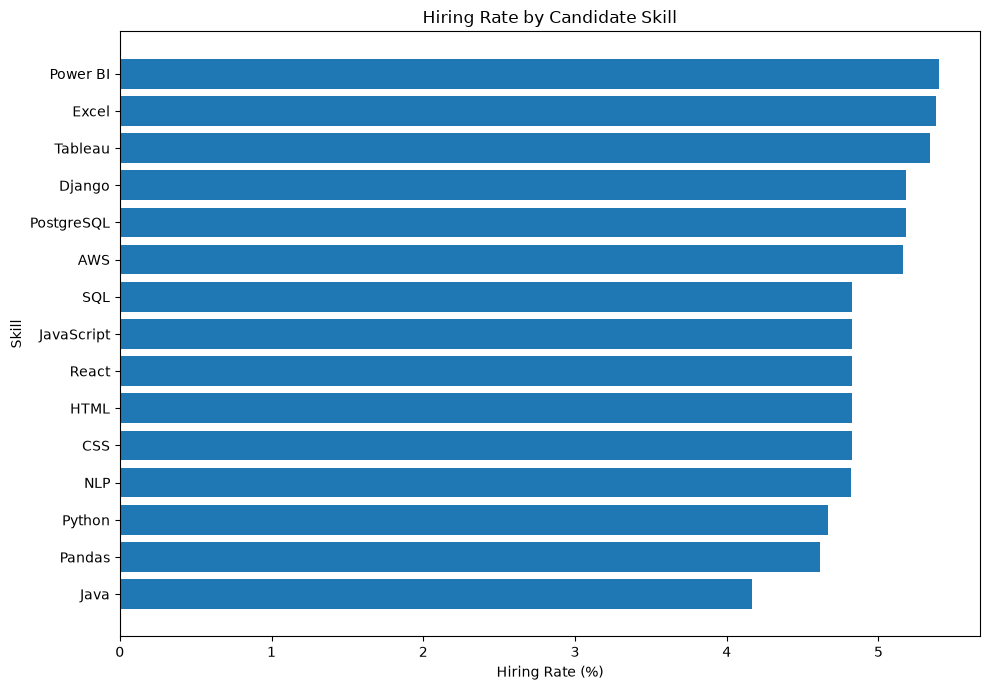

In [6]:
import matplotlib.pyplot as plt

top_skill_hiring = reliable_skills.head(15).sort_values("Hiring_Rate_%")

plt.figure(figsize=(10, 7))
plt.barh(
    top_skill_hiring["skill"],
    top_skill_hiring["Hiring_Rate_%"]
)

plt.xlabel("Hiring Rate (%)")
plt.ylabel("Skill")
plt.title("Hiring Rate by Candidate Skill")
plt.tight_layout()
plt.show()

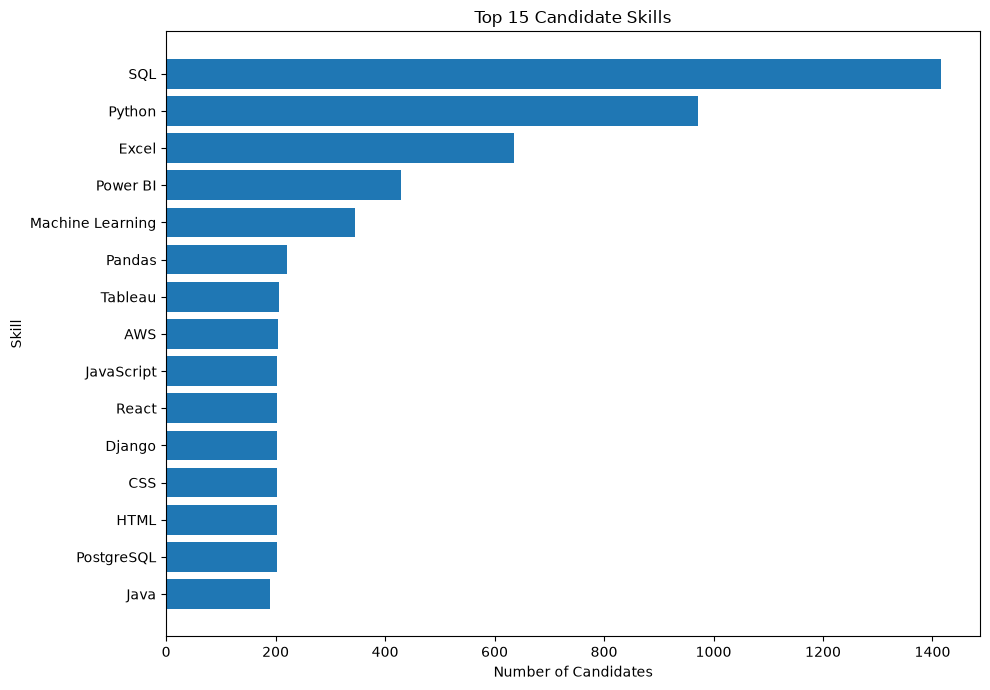

In [7]:
# Plot the most common candidate skills

top_skills = skill_counts.head(15).sort_values("Candidate_Count")

plt.figure(figsize=(10, 7))
plt.barh(
    top_skills["Skill"],
    top_skills["Candidate_Count"]
)

plt.xlabel("Number of Candidates")
plt.ylabel("Skill")
plt.title("Top 15 Candidate Skills")
plt.tight_layout()
plt.show()

In [8]:
# Save NLP results

skill_counts.to_csv(
    "../ml/skill_frequency.csv",
    index=False
)

reliable_skills.to_csv(
    "../ml/skill_hiring_analysis.csv",
    index=False
)

print("NLP results saved successfully.")

NLP results saved successfully.
